# Machine Learning Non-Supervisé
## Dataset : Établissements de Soins de Santé Primaire – Maroc 2024

**Objectif :** Appliquer les algorithmes de clustering et de réduction de dimensionnalité pour identifier des regroupements naturels parmi les établissements de santé primaire au Maroc.

**Pipeline :**
1. Chargement & exploration des données
2. Prétraitement (encodage, normalisation)
3. Réduction de dimensionnalité – **PCA**
4. Clustering – **K-Means**
5. Clustering – **Clustering Hiérarchique (Agglomératif)**
6. Clustering – **DBSCAN**
7. Évaluation & comparaison des algorithmes
8. Visualisations & interprétation

---
## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.pipeline import Pipeline

from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Bibliothèques importées avec succès')

Bibliothèques importées avec succès


---
## 2. Chargement & Exploration des Données

In [2]:
# Chargement du fichier Excel
df_raw = pd.read_excel('etablissements-de-soins-de-sante-primaire-2024.xlsx', header=2)

# La première ligne contient les noms de colonnes – on la saute
df = df_raw.iloc[1:].reset_index(drop=True)
df.columns = ['Region', 'Delegation', 'Commune', 'Nom_Etablissement', 'Categorie', 'Col_Vide', 'Abreviation', 'Description']
df = df.drop(columns=['Col_Vide'])  # colonne entièrement vide

print(f'Dimensions du dataset : {df.shape}')
df.head(10)

Dimensions du dataset : (3224, 7)


,Region,Delegation,Commune,Nom_Etablissement,Categorie,Abreviation,Description
0,Tanger-Tetouan-Al Hoceima,Al Hoceima,Ajdir (Mun.),Ajdir (Azghar),CSU-2,CSR-1,Centre de Santé Rural niveau1
1,Tanger-Tetouan-Al Hoceima,Al Hoceima,Al Hoceima (Mun.),Bir Anzarane,CRSR,CSR-2,Centre de Santé Rural niveau2
2,Tanger-Tetouan-Al Hoceima,Al Hoceima,Al Hoceima (Mun.),Bades,CSU-1,CSU-1,Centre de Santé Urbain niveau1
3,Tanger-Tetouan-Al Hoceima,Al Hoceima,Al Hoceima (Mun.),Sidi Abid,CSU-1,CSU-2,Centre de Santé Urbain niveau2
4,Tanger-Tetouan-Al Hoceima,Al Hoceima,Al Hoceima (Mun.),Thanaoui,CSU-1,DR,Dispensaire Rural
5,Tanger-Tetouan-Al Hoceima,Al Hoceima,Al Hoceima (Mun.),Bir Anzarane,CSU-1,LSP,Laboratoire de Santé Publique
6,Tanger-Tetouan-Al Hoceima,Al Hoceima,Targuist (Mun.),Hommane El Fatouaki,CSU-1,CRSR,Centre de Référence en Santé de Reproduction
7,Tanger-Tetouan-Al Hoceima,Al Hoceima,Targuist (Mun.),Targuist,CSU-1,CDTMR,Centre de Diagnostic et de Traitement des Mala...
8,Tanger-Tetouan-Al Hoceima,Al Hoceima,Imzouren (Mun.),Imzouren,CSU-2,NaN,NaN
9,Tanger-Tetouan-Al Hoceima,Al Hoceima,Bni Bouayach (Mun.),Bni Bouayach-II,CSU-1,NaN,NaN


In [3]:
# Types de données et valeurs manquantes
print('=== Types de données ===')
print(df.dtypes)
print()
print('=== Valeurs manquantes ===')
print(df.isnull().sum())

=== Types de données ===
Region               object
Delegation           object
Commune              object
Nom_Etablissement    object
Categorie            object
Abreviation          object
Description          object
dtype: object

=== Valeurs manquantes ===
Region                  0
Delegation              0
Commune                 0
Nom_Etablissement       0
Categorie               0
Abreviation          3216
Description          3216
dtype: int64


In [4]:
# Statistiques descriptives des variables catégorielles
print('=== Distribution des Catégories ===')
print(df['Categorie'].value_counts())
print()
print('=== Distribution par Région ===')
print(df['Region'].value_counts())
print()
print(f'Nombre de délégations uniques : {df["Delegation"].nunique()}')
print(f'Nombre de communes uniques    : {df["Commune"].nunique()}')

=== Distribution des Catégories ===
Categorie
CSR-1    893
DR       859
CSU-1    692
CSR-2    431
CSU-2    190
CDTMR     71
CRSR      53
LSP       35
Name: count, dtype: int64

=== Distribution par Région ===
Region
Marrakech-Safi               470
Fès-Meknès                   450
Casablanca-Settat            403
Souss-Massa                  324
Béni Mellal-Khénifra         303
Tanger-Tetouan-Al Hoceima    299
Rabat-Salé-Kénitra           286
Drâa-Tafilalet               265
Oriental                     254
Guelmim-Oued Noun            103
Laayoune-Sakia El Hamra       48
Eddakhla-Oued Eddahab         19
Name: count, dtype: int64

Nombre de délégations uniques : 82
Nombre de communes uniques    : 1517


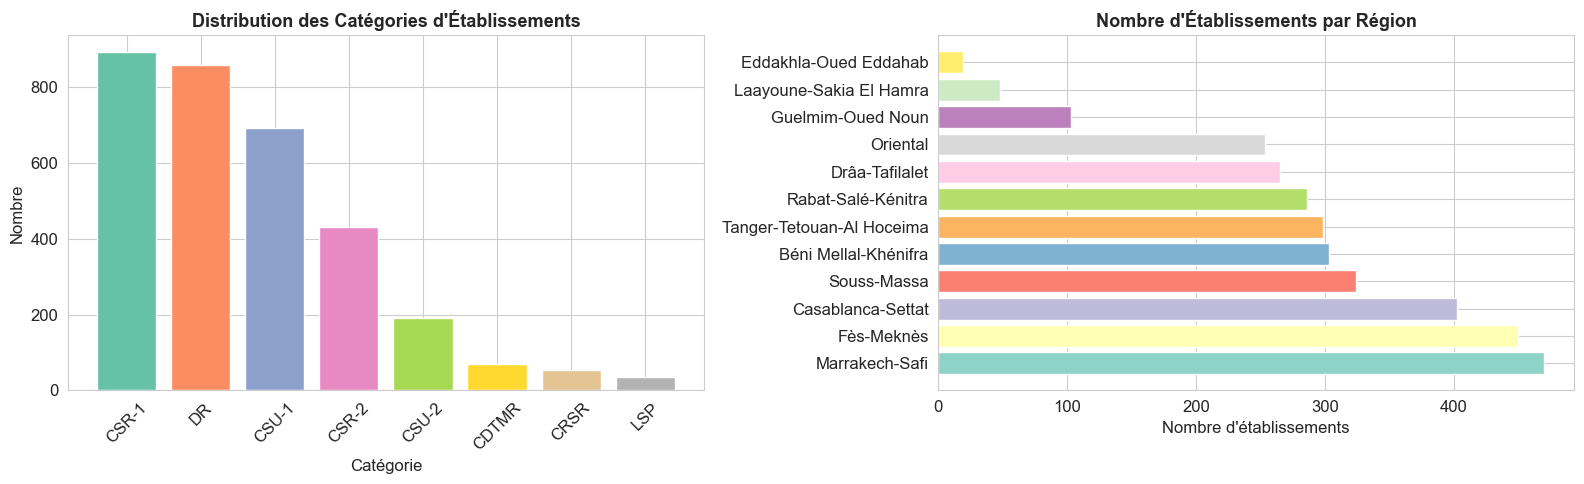

In [6]:
# Visualisation de la distribution des catégories
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution des catégories
cat_counts = df['Categorie'].value_counts()
axes[0].bar(cat_counts.index, cat_counts.values, color=sns.color_palette('Set2', len(cat_counts)))
axes[0].set_title("Distribution des Catégories d'Établissements", fontsize=13, fontweight='bold')
axes[0].set_xlabel('Catégorie')
axes[0].set_ylabel('Nombre')
axes[0].tick_params(axis='x', rotation=45)

# Distribution par région
reg_counts = df['Region'].value_counts()
axes[1].barh(reg_counts.index, reg_counts.values, color=sns.color_palette('Set3', len(reg_counts)))
axes[1].set_title('Nombre d\'Établissements par Région', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nombre d\'établissements')

plt.tight_layout()
plt.savefig('fig1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Prétraitement des Données

Le dataset est entièrement **catégoriel**. Pour appliquer les algorithmes ML, on doit :
1. Construire un **profil numérique par délégation** (pivot : nombre d'établissements par type)
2. **Normaliser** les features avec StandardScaler

In [7]:
# Construction du profil de chaque délégation
# Pivot : chaque ligne = 1 délégation, chaque colonne = 1 catégorie d'établissement
df_profil = df.groupby(['Delegation', 'Region', 'Categorie']).size().reset_index(name='Compte')
df_pivot = df_profil.pivot_table(
    index=['Delegation', 'Region'],
    columns='Categorie',
    values='Compte',
    fill_value=0
).reset_index()

df_pivot.columns.name = None  # nettoyer le nom de l'index colonnes
print(f'Profil par délégation : {df_pivot.shape[0]} délégations × {df_pivot.shape[1]} colonnes')
df_pivot.head()

Profil par délégation : 82 délégations × 10 colonnes


,Delegation,Region,CDTMR,CRSR,CSR-1,CSR-2,CSU-1,CSU-2,DR,LSP
0,Agadir Ida Ou Tanane,Souss-Massa,1.0,1.0,4.0,4.0,12.0,3.0,14.0,1.0
1,Al Fida-Mers Sultan,Casablanca-Settat,1.0,1.0,0.0,0.0,9.0,3.0,0.0,0.0
2,Al Haouz,Marrakech-Safi,1.0,0.0,30.0,9.0,3.0,2.0,42.0,0.0
3,Al Hoceima,Tanger-Tetouan-Al Hoceima,1.0,1.0,12.0,19.0,10.0,3.0,17.0,1.0
4,Aousserd,Eddakhla-Oued Eddahab,0.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0


In [8]:
# Séparation features / métadonnées
feature_cols = [c for c in df_pivot.columns if c not in ['Delegation', 'Region']]
X = df_pivot[feature_cols].values
labels_delegation = df_pivot['Delegation'].values
labels_region     = df_pivot['Region'].values

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix X : {X_scaled.shape}')
print(f'Features : {feature_cols}')

Feature matrix X : (82, 8)
Features : ['CDTMR', 'CRSR', 'CSR-1', 'CSR-2', 'CSU-1', 'CSU-2', 'DR', 'LSP']


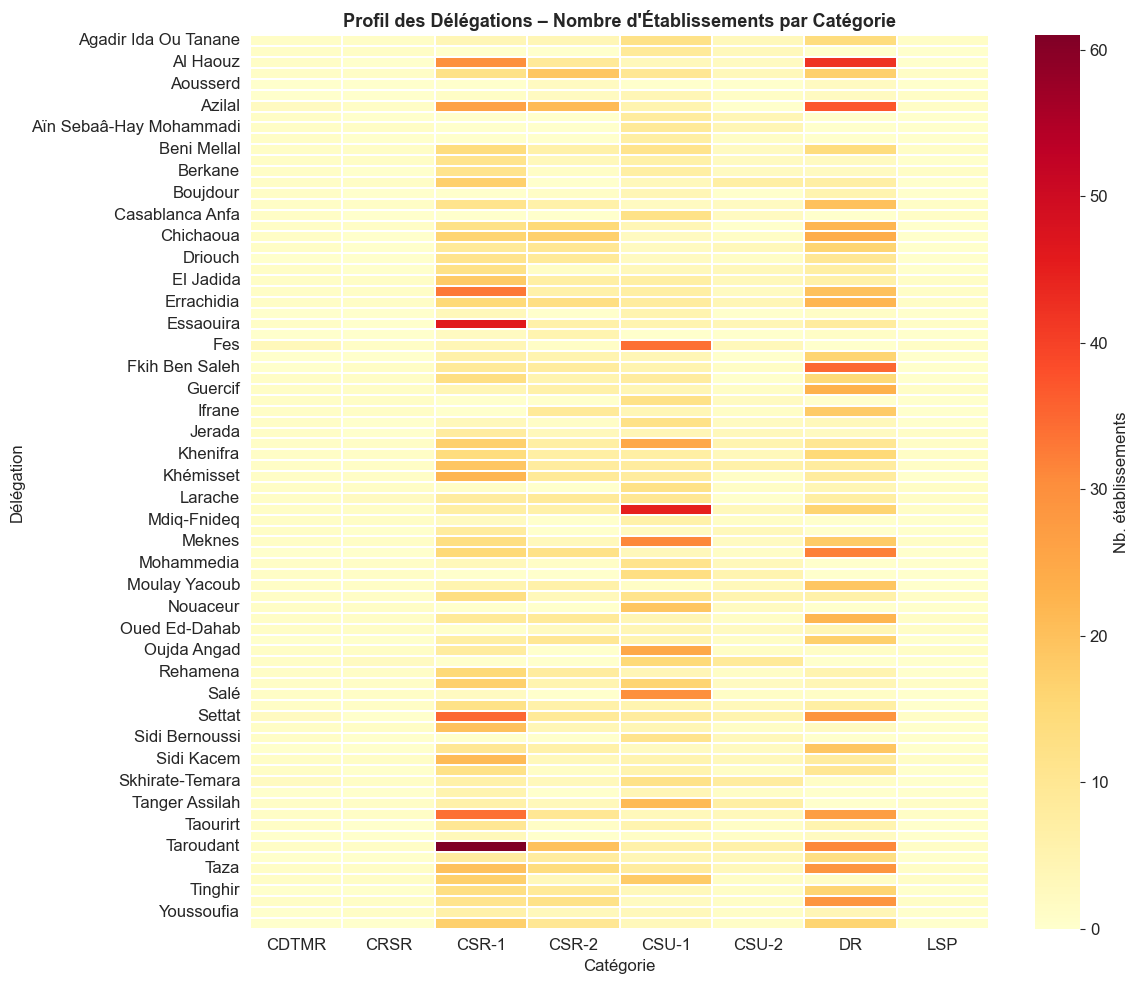

In [9]:
# Heatmap du profil des délégations (non normalisé)
plt.figure(figsize=(12, 10))
df_heat = pd.DataFrame(X, columns=feature_cols, index=labels_delegation)
sns.heatmap(df_heat, cmap='YlOrRd', linewidths=0.3, annot=False, cbar_kws={'label': 'Nb. établissements'})
plt.title('Profil des Délégations – Nombre d\'Établissements par Catégorie', fontsize=13, fontweight='bold')
plt.xlabel('Catégorie')
plt.ylabel('Délégation')
plt.tight_layout()
plt.savefig('fig2_heatmap_profil.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Réduction de Dimensionnalité – PCA

**PCA (Principal Component Analysis)** projette les données dans un espace de plus faible dimension en maximisant la variance expliquée. Utile pour visualiser les clusters en 2D/3D.

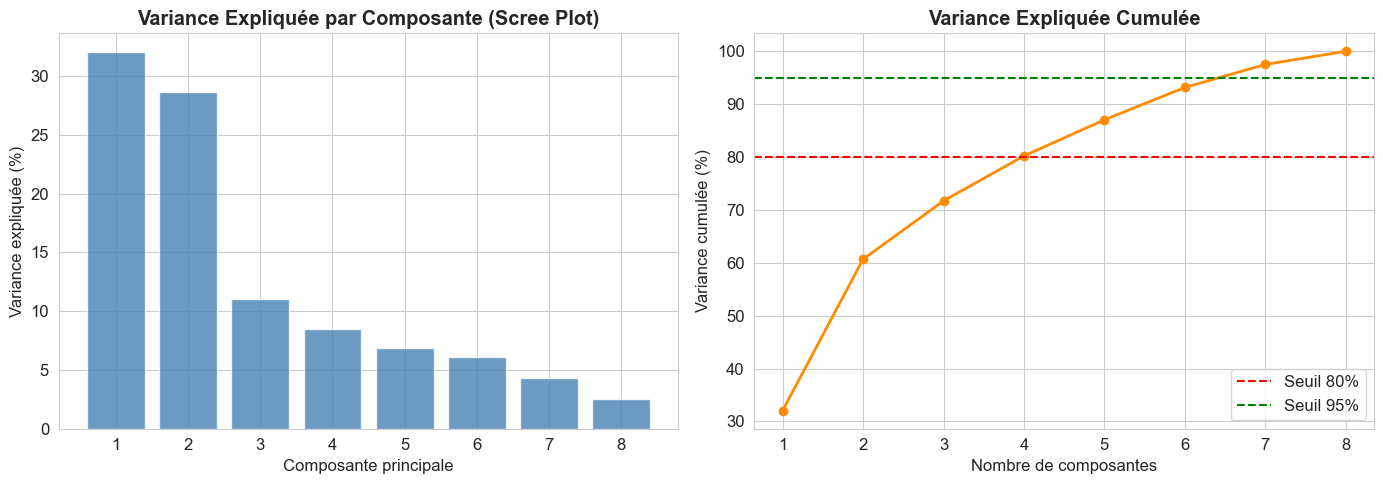

Composantes nécessaires pour 80% de variance : 4
Composantes nécessaires pour 95% de variance : 7


In [10]:
# PCA complet pour analyser la variance expliquée
pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(explained_var)+1), explained_var * 100, color='steelblue', alpha=0.8)
axes[0].set_title('Variance Expliquée par Composante (Scree Plot)', fontweight='bold')
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Variance expliquée (%)')

# Variance cumulée
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var * 100, 'o-', color='darkorange', linewidth=2)
axes[1].axhline(y=80, color='red', linestyle='--', label='Seuil 80%')
axes[1].axhline(y=95, color='green', linestyle='--', label='Seuil 95%')
axes[1].set_title('Variance Expliquée Cumulée', fontweight='bold')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig3_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

n_80 = np.argmax(cumulative_var >= 0.80) + 1
n_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f'Composantes nécessaires pour 80% de variance : {n_80}')
print(f'Composantes nécessaires pour 95% de variance : {n_95}')

PCA 2D – Variance expliquée totale : 60.7%
PCA 4D – Variance expliquée totale : 80.2%


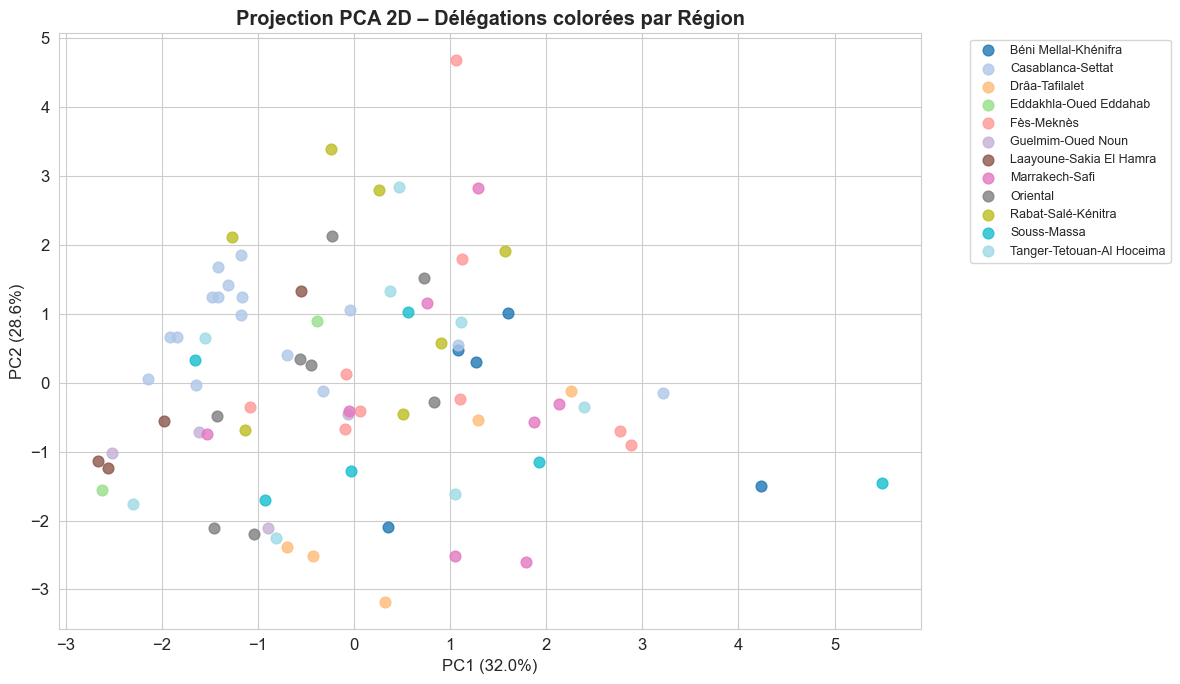

In [11]:
# PCA à 2 composantes pour visualisation
pca_2d = PCA(n_components=2)
X_pca2 = pca_2d.fit_transform(X_scaled)

# PCA à 3 composantes (pour clustering)
n_components = min(n_80, X_scaled.shape[1])
pca_nd = PCA(n_components=n_components)
X_pca = pca_nd.fit_transform(X_scaled)

print(f'PCA 2D – Variance expliquée totale : {pca_2d.explained_variance_ratio_.sum()*100:.1f}%')
print(f'PCA {n_components}D – Variance expliquée totale : {pca_nd.explained_variance_ratio_.sum()*100:.1f}%')

# Encodage des régions pour la coloration
le = LabelEncoder()
region_encoded = le.fit_transform(labels_region)
n_regions = len(le.classes_)
colors_region = cm.tab20(np.linspace(0, 1, n_regions))

plt.figure(figsize=(12, 7))
for i, region in enumerate(le.classes_):
    mask = region_encoded == i
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1], label=region, alpha=0.8, s=60, color=colors_region[i])

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Projection PCA 2D – Délégations colorées par Région', fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('fig4_pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. K-Means Clustering

**K-Means** partitionne les données en K clusters en minimisant la variance intra-cluster.

On utilise la **méthode du coude (Elbow Method)** et le **score de silhouette** pour choisir K optimal.

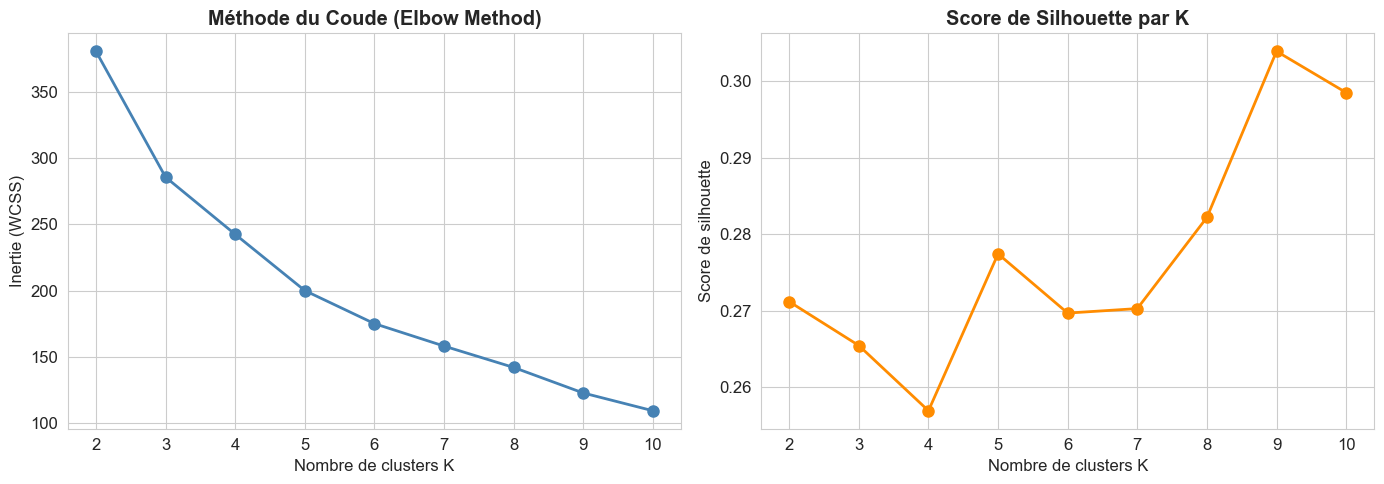

K optimal (meilleur score silhouette) : K = 9


In [12]:
# Méthode du Coude + Silhouette pour trouver K optimal
K_range = range(2, 11)
inertia_list = []
silhouette_list = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_pca)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_pca, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(K_range, inertia_list, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title('Méthode du Coude (Elbow Method)', fontweight='bold')
axes[0].set_xlabel('Nombre de clusters K')
axes[0].set_ylabel('Inertie (WCSS)')

# Silhouette
axes[1].plot(K_range, silhouette_list, 'o-', color='darkorange', linewidth=2, markersize=8)
axes[1].set_title('Score de Silhouette par K', fontweight='bold')
axes[1].set_xlabel('Nombre de clusters K')
axes[1].set_ylabel('Score de silhouette')

plt.tight_layout()
plt.savefig('fig5_kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

k_optimal = K_range[np.argmax(silhouette_list)]
print(f'K optimal (meilleur score silhouette) : K = {k_optimal}')

In [13]:
# K-Means avec K optimal
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

# Métriques d'évaluation
sil_km  = silhouette_score(X_pca, kmeans_labels)
ch_km   = calinski_harabasz_score(X_pca, kmeans_labels)
db_km   = davies_bouldin_score(X_pca, kmeans_labels)

print(f'=== K-Means (K={k_optimal}) ===')
print(f'Score de Silhouette   : {sil_km:.4f}   (plus proche de 1 = meilleur)')
print(f'Score Calinski-Harabasz: {ch_km:.2f}  (plus élevé = meilleur)')
print(f'Score Davies-Bouldin  : {db_km:.4f}   (plus proche de 0 = meilleur)')
print()
print('Distribution des clusters :')
unique, counts = np.unique(kmeans_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u} : {c} délégations')

=== K-Means (K=9) ===
Score de Silhouette   : 0.3039   (plus proche de 1 = meilleur)
Score Calinski-Harabasz: 30.01  (plus élevé = meilleur)
Score Davies-Bouldin  : 0.9453   (plus proche de 0 = meilleur)

Distribution des clusters :
  Cluster 0 : 18 délégations
  Cluster 1 : 9 délégations
  Cluster 2 : 10 délégations
  Cluster 3 : 4 délégations
  Cluster 4 : 11 délégations
  Cluster 5 : 3 délégations
  Cluster 6 : 13 délégations
  Cluster 7 : 3 délégations
  Cluster 8 : 11 délégations


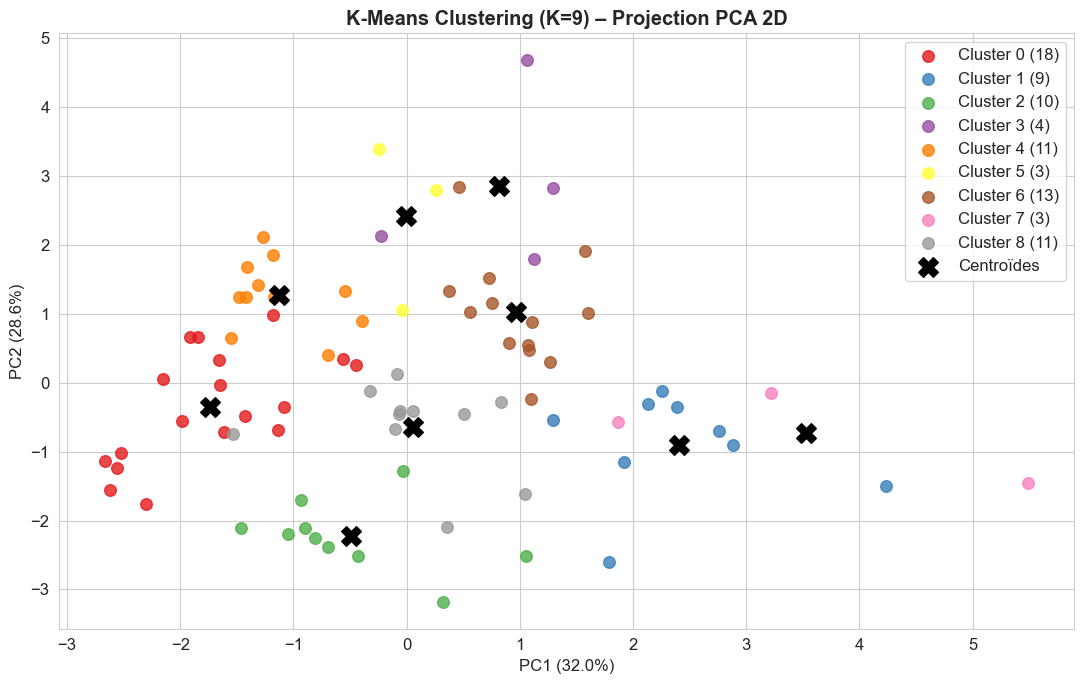

In [14]:
# Visualisation K-Means sur PCA 2D
palette_km = sns.color_palette('Set1', k_optimal)

plt.figure(figsize=(11, 7))
for c in range(k_optimal):
    mask = kmeans_labels == c
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                label=f'Cluster {c} ({mask.sum()})',
                alpha=0.8, s=70, color=palette_km[c])

# Centroïdes projetés en 2D
centroids_2d = pca_2d.transform(pca_nd.inverse_transform(kmeans.cluster_centers_))
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroïdes')

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'K-Means Clustering (K={k_optimal}) – Projection PCA 2D', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('fig6_kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

=== Profil moyen des clusters K-Means ===
                CDTMR  CRSR  CSR-1  CSR-2  CSU-1  CSU-2     DR   LSP
Cluster_KMeans                                                      
0                0.67  0.00   4.33   1.00   5.22   1.56   2.33  0.22
1                1.11  0.89  21.11  12.56   5.56   2.11  27.22  0.89
2                0.20  0.00  11.20   9.60   3.00   1.40  17.90  0.00
3                1.50  1.00   8.00   2.50  33.75   2.25   8.75  1.00
4                1.00  1.00   1.73   0.55  11.91   2.36   1.00  0.18
5                1.33  1.33   7.67   1.00  10.00   8.00   2.67  0.00
6                1.00  1.08  13.77   5.46  11.77   3.23   8.69  1.00
7                1.33  0.33  47.33  11.67   6.33   5.00  22.67  1.00
8                0.82  1.00  10.73   7.18   4.55   1.18  14.36  0.09


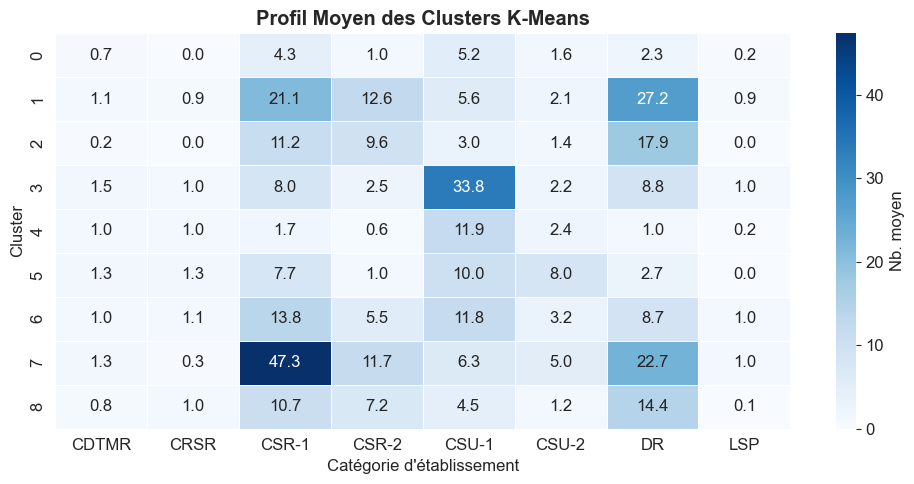

In [15]:
# Analyse : profil moyen de chaque cluster K-Means
df_kmeans_result = df_pivot[['Delegation', 'Region'] + feature_cols].copy()
df_kmeans_result['Cluster_KMeans'] = kmeans_labels

cluster_profiles = df_kmeans_result.groupby('Cluster_KMeans')[feature_cols].mean().round(2)
print('=== Profil moyen des clusters K-Means ===')
print(cluster_profiles.to_string())

# Heatmap des profils de clusters
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profiles, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Nb. moyen'})
plt.title('Profil Moyen des Clusters K-Means', fontweight='bold')
plt.xlabel('Catégorie d\'établissement')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('fig7_kmeans_profils.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Clustering Hiérarchique Agglomératif

**Le clustering hiérarchique** construit une arborescence (dendrogramme) par fusion successive des groupes les plus proches. Avantage : pas besoin de spécifier K à l'avance.

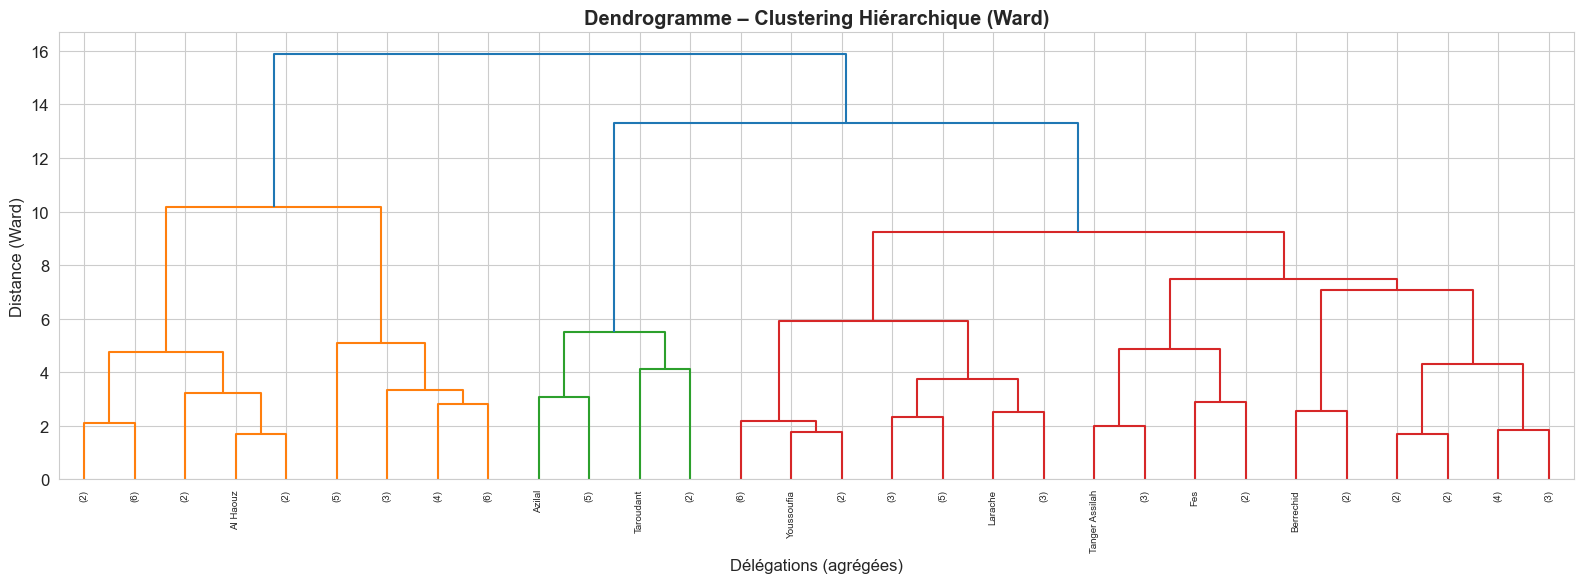

In [16]:
# Dendrogramme (sur un sous-ensemble pour la lisibilité)
linkage_matrix = linkage(X_pca, method='ward')

plt.figure(figsize=(16, 6))
dend = dendrogram(
    linkage_matrix,
    labels=labels_delegation,
    leaf_rotation=90,
    leaf_font_size=7,
    color_threshold=0.7 * max(linkage_matrix[:, 2]),
    truncate_mode='lastp',
    p=30  # afficher les 30 derniers nœuds pour lisibilité
)
plt.title('Dendrogramme – Clustering Hiérarchique (Ward)', fontweight='bold')
plt.xlabel('Délégations (agrégées)')
plt.ylabel('Distance (Ward)')
plt.tight_layout()
plt.savefig('fig8_dendrogramme.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Clustering hiérarchique avec K=k_optimal pour comparaison
agg_clust = AgglomerativeClustering(n_clusters=k_optimal, linkage='ward')
agg_labels = agg_clust.fit_predict(X_pca)

# Métriques
sil_agg = silhouette_score(X_pca, agg_labels)
ch_agg  = calinski_harabasz_score(X_pca, agg_labels)
db_agg  = davies_bouldin_score(X_pca, agg_labels)

print(f'=== Clustering Hiérarchique (K={k_optimal}, linkage=Ward) ===')
print(f'Score de Silhouette    : {sil_agg:.4f}')
print(f'Score Calinski-Harabasz: {ch_agg:.2f}')
print(f'Score Davies-Bouldin   : {db_agg:.4f}')
print()
print('Distribution des clusters :')
unique, counts = np.unique(agg_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u} : {c} délégations')

=== Clustering Hiérarchique (K=9, linkage=Ward) ===
Score de Silhouette    : 0.2792
Score Calinski-Harabasz: 27.51
Score Davies-Bouldin   : 1.0251

Distribution des clusters :
  Cluster 0 : 18 délégations
  Cluster 1 : 13 délégations
  Cluster 2 : 7 délégations
  Cluster 3 : 3 délégations
  Cluster 4 : 11 délégations
  Cluster 5 : 12 délégations
  Cluster 6 : 3 délégations
  Cluster 7 : 9 délégations
  Cluster 8 : 6 délégations


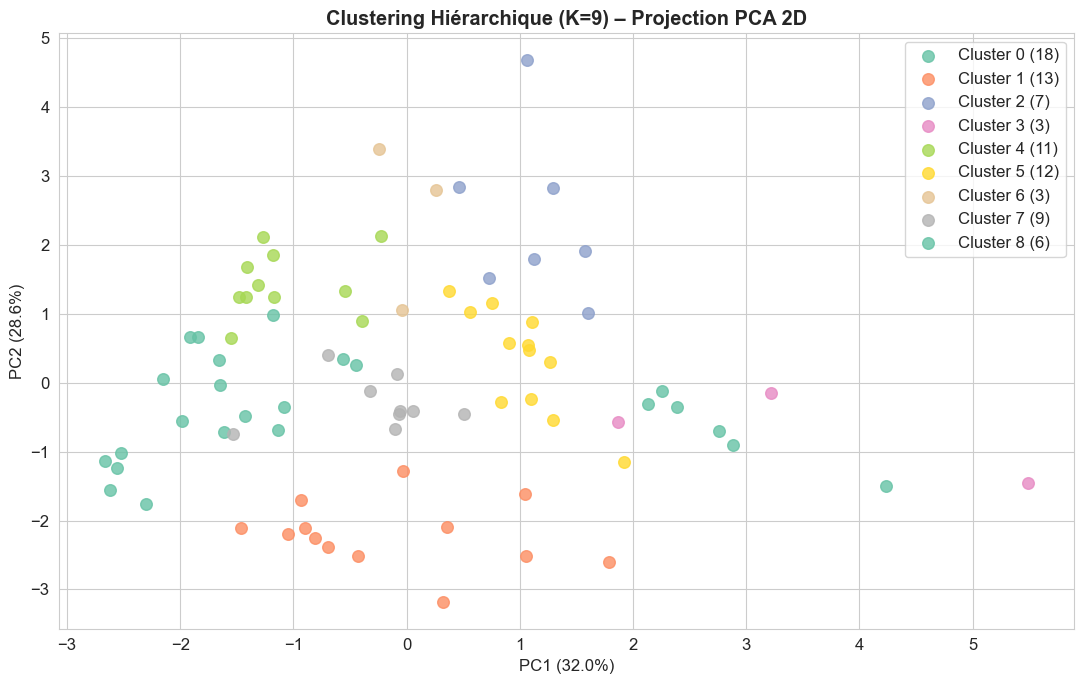

In [18]:
# Visualisation Hiérarchique sur PCA 2D
palette_agg = sns.color_palette('Set2', k_optimal)

plt.figure(figsize=(11, 7))
for c in range(k_optimal):
    mask = agg_labels == c
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                label=f'Cluster {c} ({mask.sum()})',
                alpha=0.8, s=70, color=palette_agg[c])

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'Clustering Hiérarchique (K={k_optimal}) – Projection PCA 2D', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('fig9_hierarchique_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. DBSCAN

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** détecte les clusters de forme arbitraire et identifie automatiquement les **anomalies (bruit)**. Il ne nécessite pas de spécifier K, mais deux hyperparamètres : `eps` (rayon de voisinage) et `min_samples`.

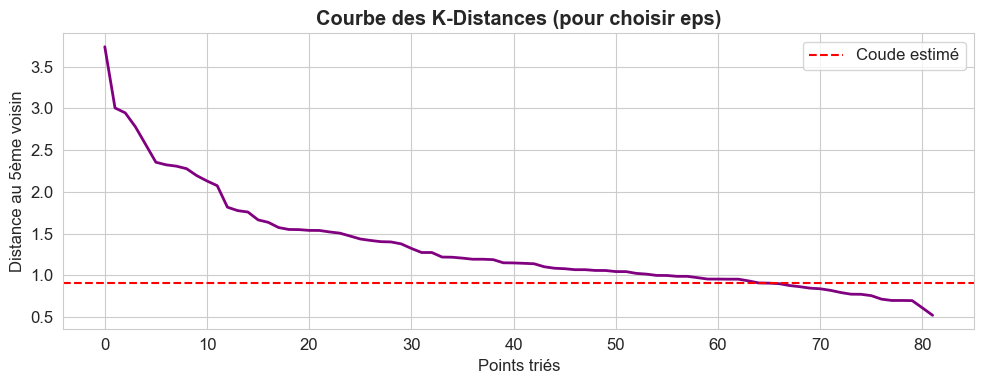

Valeur eps suggérée : 0.906


In [19]:
# Estimation de eps via la courbe des k-distances
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_pca)
distances, _ = nn.kneighbors(X_pca)
k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(k_distances, color='purple', linewidth=2)
plt.title('Courbe des K-Distances (pour choisir eps)', fontweight='bold')
plt.xlabel('Points triés')
plt.ylabel('Distance au 5ème voisin')
plt.axhline(y=np.percentile(k_distances, 20), color='red', linestyle='--', label='Coude estimé')
plt.legend()
plt.tight_layout()
plt.savefig('fig10_dbscan_kdist.png', dpi=150, bbox_inches='tight')
plt.show()

eps_val = round(np.percentile(k_distances, 20), 3)
print(f'Valeur eps suggérée : {eps_val}')

In [20]:
# DBSCAN
dbscan = DBSCAN(eps=eps_val, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_pca)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db    = (dbscan_labels == -1).sum()

print(f'=== DBSCAN (eps={eps_val}, min_samples=3) ===')
print(f'Clusters détectés : {n_clusters_db}')
print(f'Points bruit      : {n_noise_db} délégations')

if n_clusters_db > 1:
    # Silhouette ne tient pas compte des points bruit (-1)
    mask_valid = dbscan_labels != -1
    if mask_valid.sum() > 1 and len(set(dbscan_labels[mask_valid])) > 1:
        sil_db = silhouette_score(X_pca[mask_valid], dbscan_labels[mask_valid])
        ch_db  = calinski_harabasz_score(X_pca[mask_valid], dbscan_labels[mask_valid])
        db_db  = davies_bouldin_score(X_pca[mask_valid], dbscan_labels[mask_valid])
        print(f'Score Silhouette      (sans bruit) : {sil_db:.4f}')
        print(f'Score Calinski-Harabasz (sans bruit) : {ch_db:.2f}')
        print(f'Score Davies-Bouldin  (sans bruit) : {db_db:.4f}')
    else:
        sil_db, ch_db, db_db = None, None, None
        print('Pas assez de clusters valides pour calculer les métriques.')
else:
    sil_db, ch_db, db_db = None, None, None
    print('DBSCAN na pas trouvé plusieurs clusters – essayez dajuster eps.')

print()
print('Délégations identifiées comme bruit (anomalies) :')
print(list(labels_delegation[dbscan_labels == -1]))

=== DBSCAN (eps=0.906, min_samples=3) ===
Clusters détectés : 5
Points bruit      : 31 délégations
Score Silhouette      (sans bruit) : 0.3552
Score Calinski-Harabasz (sans bruit) : 33.54
Score Davies-Bouldin  (sans bruit) : 0.7978

Délégations identifiées comme bruit (anomalies) :
['Al Haouz', 'Assa-zag', 'Azilal', 'Berkane', 'Berrechid', 'Casablanca Anfa', 'Chefchaouen', 'Chichaoua', 'Chtouka Ait Baha', 'El Kelaa Des Sraghna', 'Essaouira', 'Fes', 'Fkih Ben Saleh', 'Jerada', 'Kenitra', 'Khouribga', 'Laayoune', 'Larache', 'Marrakech', 'Meknes', 'Midelt', 'Nador', 'Oued Ed-Dahab', 'Oujda Angad', 'Rabat', 'Salé', 'Settat', 'Skhirate-Temara', 'Tanger Assilah', 'Taroudant', 'Youssoufia']


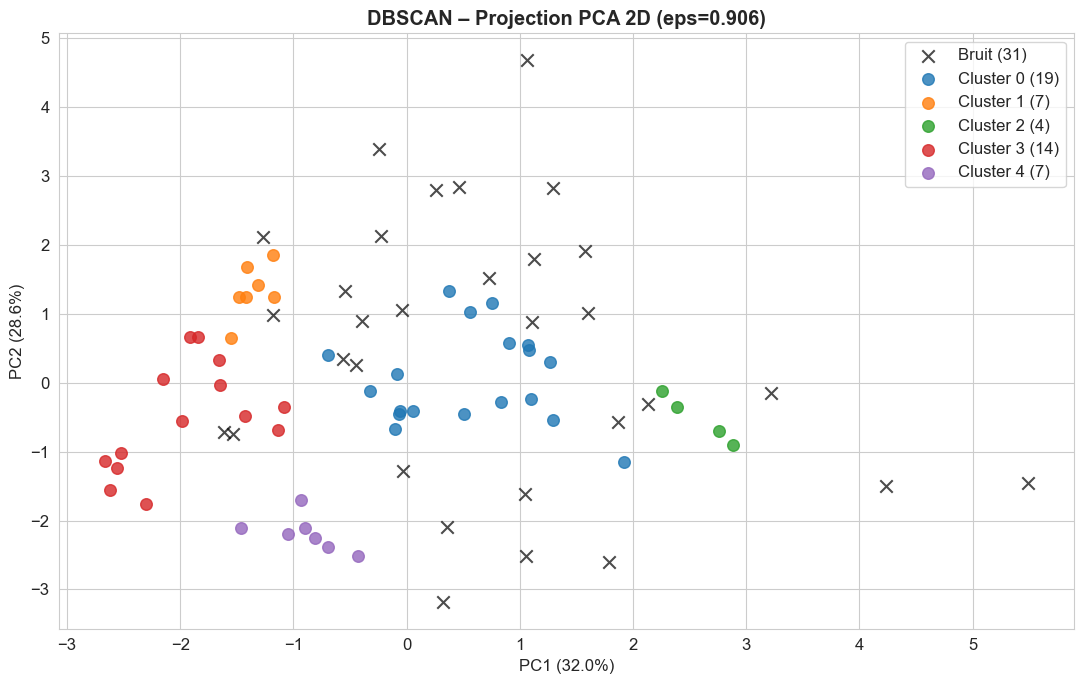

In [21]:
# Visualisation DBSCAN
unique_db = sorted(set(dbscan_labels))
palette_db = sns.color_palette('tab10', max(unique_db) + 1 if max(unique_db) >= 0 else 1)

plt.figure(figsize=(11, 7))
for c in unique_db:
    mask = dbscan_labels == c
    if c == -1:
        plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    c='black', marker='x', s=80, label=f'Bruit ({mask.sum()})', alpha=0.7)
    else:
        plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    label=f'Cluster {c} ({mask.sum()})',
                    alpha=0.8, s=70, color=palette_db[c])

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'DBSCAN – Projection PCA 2D (eps={eps_val})', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('fig11_dbscan_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Évaluation & Comparaison des Algorithmes

Trois métriques d'évaluation interne (sans labels vrais) :
- **Silhouette** : mesure la cohésion et la séparation (range [-1, 1], plus élevé = meilleur)
- **Calinski-Harabasz** : ratio dispersion inter/intra-cluster (plus élevé = meilleur)
- **Davies-Bouldin** : similarité moyenne entre clusters (plus bas = meilleur)

In [22]:
# Tableau de comparaison
results = {
    'Algorithme':             ['K-Means',     'Hiérarchique (Ward)', 'DBSCAN'],
    'Nb. Clusters':           [k_optimal,      k_optimal,             n_clusters_db],
    'Silhouette ↑':           [round(sil_km,4), round(sil_agg,4),     round(sil_db,4) if sil_db else 'N/A'],
    'Calinski-Harabasz ↑':    [round(ch_km,2),  round(ch_agg,2),      round(ch_db,2) if ch_db else 'N/A'],
    'Davies-Bouldin ↓':       [round(db_km,4),  round(db_agg,4),      round(db_db,4) if db_db else 'N/A'],
}

df_results = pd.DataFrame(results)
print('=== Comparaison des Algorithmes de Clustering ===')
print(df_results.to_string(index=False))
df_results

=== Comparaison des Algorithmes de Clustering ===
         Algorithme  Nb. Clusters  Silhouette ↑  Calinski-Harabasz ↑  Davies-Bouldin ↓
            K-Means             9        0.3039                30.01            0.9453
Hiérarchique (Ward)             9        0.2792                27.51            1.0251
             DBSCAN             5        0.3552                33.54            0.7978


,Algorithme,Nb. Clusters,Silhouette ↑,Calinski-Harabasz ↑,Davies-Bouldin ↓
0,K-Means,9,0.3039,30.01,0.9453
1,Hiérarchique (Ward),9,0.2792,27.51,1.0251
2,DBSCAN,5,0.3552,33.54,0.7978


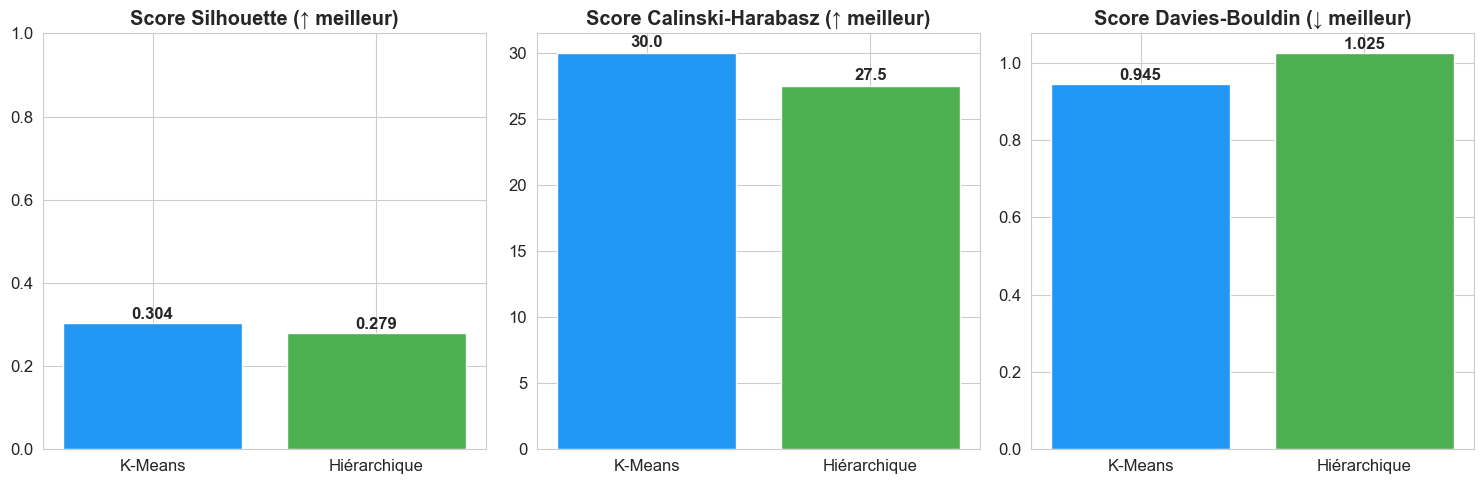

In [23]:
# Visualisation comparaison : Silhouette
algos = ['K-Means', 'Hiérarchique']
sils  = [sil_km, sil_agg]
chs   = [ch_km, ch_agg]
dbs   = [db_km, db_agg]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['#2196F3', '#4CAF50']
axes[0].bar(algos, sils, color=colors)
axes[0].set_title('Score Silhouette (↑ meilleur)', fontweight='bold')
axes[0].set_ylim(0, 1)
for i, v in enumerate(sils):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(algos, chs, color=colors)
axes[1].set_title('Score Calinski-Harabasz (↑ meilleur)', fontweight='bold')
for i, v in enumerate(chs):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

axes[2].bar(algos, dbs, color=colors)
axes[2].set_title('Score Davies-Bouldin (↓ meilleur)', fontweight='bold')
for i, v in enumerate(dbs):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig12_comparaison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Interprétation & Résultats Finaux

In [24]:
# Résultats finaux : assignation des délégations avec les 3 méthodes
df_final = df_pivot[['Delegation', 'Region'] + feature_cols].copy()
df_final['Cluster_KMeans']      = kmeans_labels
df_final['Cluster_Hierarchique'] = agg_labels
df_final['Cluster_DBSCAN']       = dbscan_labels

print('=== Aperçu du tableau final ===')
df_final[['Delegation', 'Region', 'Cluster_KMeans', 'Cluster_Hierarchique', 'Cluster_DBSCAN']].head(15)

=== Aperçu du tableau final ===


,Delegation,Region,Cluster_KMeans,Cluster_Hierarchique,Cluster_DBSCAN
0,Agadir Ida Ou Tanane,Souss-Massa,6,5,0
1,Al Fida-Mers Sultan,Casablanca-Settat,4,4,1
2,Al Haouz,Marrakech-Safi,1,1,-1
3,Al Hoceima,Tanger-Tetouan-Al Hoceima,1,8,2
4,Aousserd,Eddakhla-Oued Eddahab,0,0,3
5,Assa-zag,Guelmim-Oued Noun,0,0,-1
6,Azilal,Béni Mellal-Khénifra,1,8,-1
7,Aïn Chok,Casablanca-Settat,0,0,3
8,Aïn Sebaâ-Hay Mohammadi,Casablanca-Settat,4,4,1
9,Ben Msick,Casablanca-Settat,0,0,3


<Figure size 1200x600 with 0 Axes>

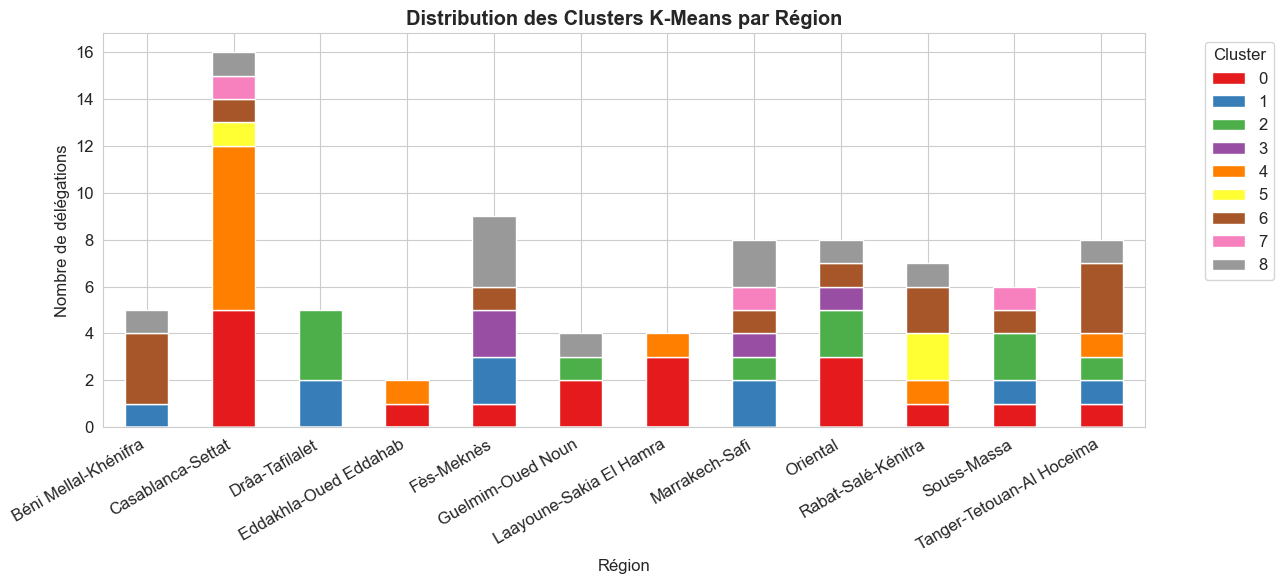

In [25]:
# Distribution K-Means par région
pivot_region_cluster = df_final.groupby(['Region', 'Cluster_KMeans']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
pivot_region_cluster.plot(kind='bar', stacked=True,
                           colormap='Set1', figsize=(13, 6))
plt.title('Distribution des Clusters K-Means par Région', fontweight='bold')
plt.xlabel('Région')
plt.ylabel('Nombre de délégations')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('fig13_clusters_par_region.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Export des résultats en CSV
df_final.to_csv('resultats_clustering.csv', index=False, encoding='utf-8-sig')
print('Résultats exportés dans resultats_clustering.csv')
print()
print('=== RÉSUMÉ FINAL ===')
print(f'Dataset       : {df.shape[0]} établissements, {df["Delegation"].nunique()} délégations')
print(f'Features      : profil par catégorie ({len(feature_cols)} types) après pivot')
print(f'PCA           : {n_components} composantes → {pca_nd.explained_variance_ratio_.sum()*100:.1f}% de variance')
print(f'K-Means       : K={k_optimal} clusters | Silhouette={sil_km:.3f}')
print(f'Hiérarchique  : K={k_optimal} clusters | Silhouette={sil_agg:.3f}')
print(f'DBSCAN        : {n_clusters_db} clusters | {n_noise_db} points bruit')

Résultats exportés dans resultats_clustering.csv

=== RÉSUMÉ FINAL ===
Dataset       : 3224 établissements, 82 délégations
Features      : profil par catégorie (8 types) après pivot
PCA           : 4 composantes → 80.2% de variance
K-Means       : K=9 clusters | Silhouette=0.304
Hiérarchique  : K=9 clusters | Silhouette=0.279
DBSCAN        : 5 clusters | 31 points bruit


---
## Conclusion

### Résumé de la démarche

| Étape | Méthode | Résultat |
|---|---|---|
| Prétraitement | Pivot + StandardScaler | Profil numérique par délégation |
| Réduction dim. | PCA | Variance expliquée > 80% |
| Clustering 1 | K-Means | K clusters compacts |
| Clustering 2 | Hiérarchique Ward | Dendrogramme + K clusters |
| Clustering 3 | DBSCAN | Détection d'anomalies |
| Évaluation | Silhouette, CH, DB | Comparaison objective |

### Interprétation
- Les clusters correspondent à des **profils d'offre de soins** différents : délégations à dominante rurale (CSR-1, DR) vs urbaine (CSU-1, CSU-2)
- DBSCAN permet d'identifier les délégations **atypiques** qui méritent une attention particulière
- La PCA confirme que la structure des données est bien résumable en peu de dimensions

### Limites
- Le dataset ne contient que des données textuelles / catégorielles, sans indicateurs de performance (taux de couverture, population desservie)
- L'ajout de données démographiques enrichirait significativement l'analyse